In [2]:
import pandas as pd
import numpy as np

df = pd.read_csv("Telco-Customer-Churn.csv", sep=";")

print("Shape:", df.shape)
df.head()

Shape: (7043, 21)


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [3]:
blank_mask = df['TotalCharges'].str.strip() == ''
print("Number of blank TotalCharges rows:", blank_mask.sum())
df[blank_mask][['customerID', 'tenure', 'MonthlyCharges', 'TotalCharges', 'Churn']]

Number of blank TotalCharges rows: 11


,customerID,tenure,MonthlyCharges,TotalCharges,Churn
488,4472-LVYGI,0,52.55,,No
753,3115-CZMZD,0,20.25,,No
936,5709-LVOEQ,0,80.85,,No
1082,4367-NUYAO,0,25.75,,No
1340,1371-DWPAZ,0,56.05,,No
3331,7644-OMVMY,0,19.85,,No
3826,3213-VVOLG,0,25.35,,No
4380,2520-SGTTA,0,20.00,,No
5218,2923-ARZLG,0,19.70,,No
6670,4075-WKNIU,0,73.35,,No


In [4]:
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'].str.strip(), errors='coerce')

print("NaNs after conversion:", df['TotalCharges'].isna().sum())

df['TotalCharges'] = df['TotalCharges'].fillna(0)

print("NaNs after fill:", df['TotalCharges'].isna().sum())
df['TotalCharges'].describe()

NaNs after conversion: 11
NaNs after fill: 0


count    7043.000000
mean     2279.734304
std      2266.794470
min         0.000000
25%       398.550000
50%      1394.550000
75%      3786.600000
max      8684.800000
Name: TotalCharges, dtype: float64

In [5]:
df_clean = df.drop(columns=['customerID'])
print(df_clean.shape)

(7043, 20)


In [6]:
df_clean['Churn'] = df_clean['Churn'].map({'Yes': 1, 'No': 0})
df_clean['Churn'].value_counts()

Churn
0    5174
1    1869
Name: count, dtype: int64

In [7]:
categorical_cols = df_clean.select_dtypes(include='object').columns.tolist()
print("Categorical columns to encode:", categorical_cols)

df_encoded = pd.get_dummies(df_clean, columns=categorical_cols, drop_first=True)
print("Shape after encoding:", df_encoded.shape)
df_encoded.head()

Categorical columns to encode: ['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']
Shape after encoding: (7043, 31)


,SeniorCitizen,tenure,MonthlyCharges,TotalCharges,Churn,gender_Male,Partner_Yes,Dependents_Yes,PhoneService_Yes,MultipleLines_No phone service,...,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaperlessBilling_Yes,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,0,1,29.85,29.85,0,False,True,False,False,True,...,False,False,False,False,False,False,True,False,True,False
1,0,34,56.95,1889.50,0,True,False,False,True,False,...,False,False,False,False,True,False,False,False,False,True
2,0,2,53.85,108.15,1,True,False,False,True,False,...,False,False,False,False,False,False,True,False,False,True
3,0,45,42.30,1840.75,0,True,False,False,False,True,...,False,False,False,False,True,False,False,False,False,False
4,0,2,70.70,151.65,1,False,False,False,True,False,...,False,False,False,False,False,False,True,False,True,False


In [8]:
counts = df_encoded['Churn'].value_counts()
pct = df_encoded['Churn'].value_counts(normalize=True) * 100
print(counts)
print(pct.round(2))

Churn
0    5174
1    1869
Name: count, dtype: int64
Churn
0    73.46
1    26.54
Name: proportion, dtype: float64


In [9]:
bool_cols = df_encoded.select_dtypes(include='bool').columns.tolist()
print("Boolean columns to convert:", bool_cols)

df_encoded[bool_cols] = df_encoded[bool_cols].astype(int)
df_encoded.head()

Boolean columns to convert: ['gender_Male', 'Partner_Yes', 'Dependents_Yes', 'PhoneService_Yes', 'MultipleLines_No phone service', 'MultipleLines_Yes', 'InternetService_Fiber optic', 'InternetService_No', 'OnlineSecurity_No internet service', 'OnlineSecurity_Yes', 'OnlineBackup_No internet service', 'OnlineBackup_Yes', 'DeviceProtection_No internet service', 'DeviceProtection_Yes', 'TechSupport_No internet service', 'TechSupport_Yes', 'StreamingTV_No internet service', 'StreamingTV_Yes', 'StreamingMovies_No internet service', 'StreamingMovies_Yes', 'Contract_One year', 'Contract_Two year', 'PaperlessBilling_Yes', 'PaymentMethod_Credit card (automatic)', 'PaymentMethod_Electronic check', 'PaymentMethod_Mailed check']


,SeniorCitizen,tenure,MonthlyCharges,TotalCharges,Churn,gender_Male,Partner_Yes,Dependents_Yes,PhoneService_Yes,MultipleLines_No phone service,...,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaperlessBilling_Yes,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,0,1,29.85,29.85,0,0,1,0,0,1,...,0,0,0,0,0,0,1,0,1,0
1,0,34,56.95,1889.50,0,1,0,0,1,0,...,0,0,0,0,1,0,0,0,0,1
2,0,2,53.85,108.15,1,1,0,0,1,0,...,0,0,0,0,0,0,1,0,0,1
3,0,45,42.30,1840.75,0,1,0,0,0,1,...,0,0,0,0,1,0,0,0,0,0
4,0,2,70.70,151.65,1,0,0,0,1,0,...,0,0,0,0,0,0,1,0,1,0


In [10]:
df_encoded.to_csv("telco_cleaned.csv", index=False)
print("Saved! Shape:", df_encoded.shape)

Saved! Shape: (7043, 31)


In [15]:
#normalization

from sklearn.preprocessing import MinMaxScaler

df = pd.read_csv("telco_cleaned.csv")

# Continuous columns only — all others are already binary/OHE
cols_to_scale = ["tenure", "MonthlyCharges", "TotalCharges"]

scaler = MinMaxScaler()
df[cols_to_scale] = scaler.fit_transform(df[cols_to_scale])

df.to_csv("telco_normalized.csv", index=False)
print("Done:", df.shape)
print(df[cols_to_scale].describe().round(3))

Done: (7043, 31)
         tenure  MonthlyCharges  TotalCharges
count  7043.000        7043.000      7043.000
mean      0.450           0.463         0.262
std       0.341           0.299         0.261
min       0.000           0.000         0.000
25%       0.125           0.172         0.046
50%       0.403           0.518         0.161
75%       0.764           0.712         0.436
max       1.000           1.000         1.000


In [16]:
df_scaled.to_csv("telco_normalized.csv", index=False)
print("Saved! Shape:", df_scaled.shape)

Saved! Shape: (7043, 31)


In [17]:
#splitting data 

from sklearn.model_selection import train_test_split
X = df_scaled.drop(columns=['Churn'])
y = df_scaled['Churn']
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)
print("\nTrain churn distribution:")
print(y_train.value_counts(normalize=True).round(4) * 100)
print("\nTest churn distribution:")
print(y_test.value_counts(normalize=True).round(4) * 100)

Train shape: (5634, 30)
Test shape: (1409, 30)

Train churn distribution:
Churn
0    73.46
1    26.54
Name: proportion, dtype: float64

Test churn distribution:
Churn
0    73.46
1    26.54
Name: proportion, dtype: float64


In [21]:
import sys
!{sys.executable} -m pip install imbalanced-learn

In [22]:
#Augmentation

from imblearn.over_sampling import SMOTE

# Apply SMOTE only on training set
smote = SMOTE(sampling_strategy='auto', random_state=42)
X_train_sm, y_train_sm = smote.fit_resample(X_train, y_train)

print("Before SMOTE:")
print(f"  Train shape: {X_train.shape}")
print(f"  Churn distribution:\n{y_train.value_counts(normalize=True).round(4) * 100}")

print("\nAfter SMOTE:")
print(f"  Train shape: {X_train_sm.shape}")
print(f"  Churn distribution:\n{pd.Series(y_train_sm).value_counts(normalize=True).round(4) * 100}")

print("\nTest set (unchanged):")
print(f"  Test shape: {X_test.shape}")
print(f"  Churn distribution:\n{y_test.value_counts(normalize=True).round(4) * 100}")

Before SMOTE:
  Train shape: (5634, 30)
  Churn distribution:
Churn
0    73.46
1    26.54
Name: proportion, dtype: float64

After SMOTE:
  Train shape: (8278, 30)
  Churn distribution:
Churn
0    50.0
1    50.0
Name: proportion, dtype: float64

Test set (unchanged):
  Test shape: (1409, 30)
  Churn distribution:
Churn
0    73.46
1    26.54
Name: proportion, dtype: float64


In [23]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix

# --- Model 1: Trained on IMBALANCED data (baseline) ---
rf_baseline = RandomForestClassifier(n_estimators=100, random_state=42)
rf_baseline.fit(X_train, y_train)

y_pred_baseline = rf_baseline.predict(X_test)

print("=== Random Forest — IMBALANCED (Baseline) ===")
print(classification_report(y_test, y_pred_baseline))

# --- Model 2: Trained on SMOTE-balanced data ---
rf_smote = RandomForestClassifier(n_estimators=100, random_state=42)
rf_smote.fit(X_train_sm, y_train_sm)

y_pred_smote = rf_smote.predict(X_test)

print("=== Random Forest — SMOTE Balanced ===")
print(classification_report(y_test, y_pred_smote))

=== Random Forest — IMBALANCED (Baseline) ===
              precision    recall  f1-score   support

           0       0.83      0.89      0.86      1035
           1       0.62      0.50      0.55       374

    accuracy                           0.79      1409
   macro avg       0.73      0.69      0.71      1409
weighted avg       0.78      0.79      0.78      1409

=== Random Forest — SMOTE Balanced ===
              precision    recall  f1-score   support

           0       0.86      0.82      0.84      1035
           1       0.55      0.64      0.59       374

    accuracy                           0.77      1409
   macro avg       0.71      0.73      0.72      1409
weighted avg       0.78      0.77      0.77      1409



In [26]:
import sys
!{sys.executable} -m pip install shap

   ---------------------------------------- 0.0/39.2 MB ? eta -:--:--
   ---------------------------------------- 0.3/39.2 MB ? eta -:--:--
    --------------------------------------- 0.5/39.2 MB 1.1 MB/s eta 0:00:35
    --------------------------------------- 0.5/39.2 MB 1.1 MB/s eta 0:00:35
    --------------------------------------- 0.8/39.2 MB 1.1 MB/s eta 0:00:36
   - -------------------------------------- 1.0/39.2 MB 1.1 MB/s eta 0:00:36
   - -------------------------------------- 1.3/39.2 MB 1.1 MB/s eta 0:00:35
   - -------------------------------------- 1.6/39.2 MB 1.1 MB/s eta 0:00:36
   - -------------------------------------- 1.8/39.2 MB 1.1 MB/s eta 0:00:35
   -- ------------------------------------- 2.1/39.2 MB 1.1 MB/s eta 0:00:34
   -- ------------------------------------- 2.4/39.2 MB 1.1 MB/s eta 0:00:34
   -- ------------------------------------- 2.6/39.2 MB 1.1 MB/s eta 0:00:34
   -- ------------------------------------- 2.9/39.2 MB 1.1 MB/s eta 0:00:34
   --- ------

  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.


In [32]:
import shap
import numpy as np

# Vérifie d'abord la structure
print(type(shap_values_baseline))
print(np.array(shap_values_baseline).shape)

<class 'numpy.ndarray'>
(1409, 30, 2)


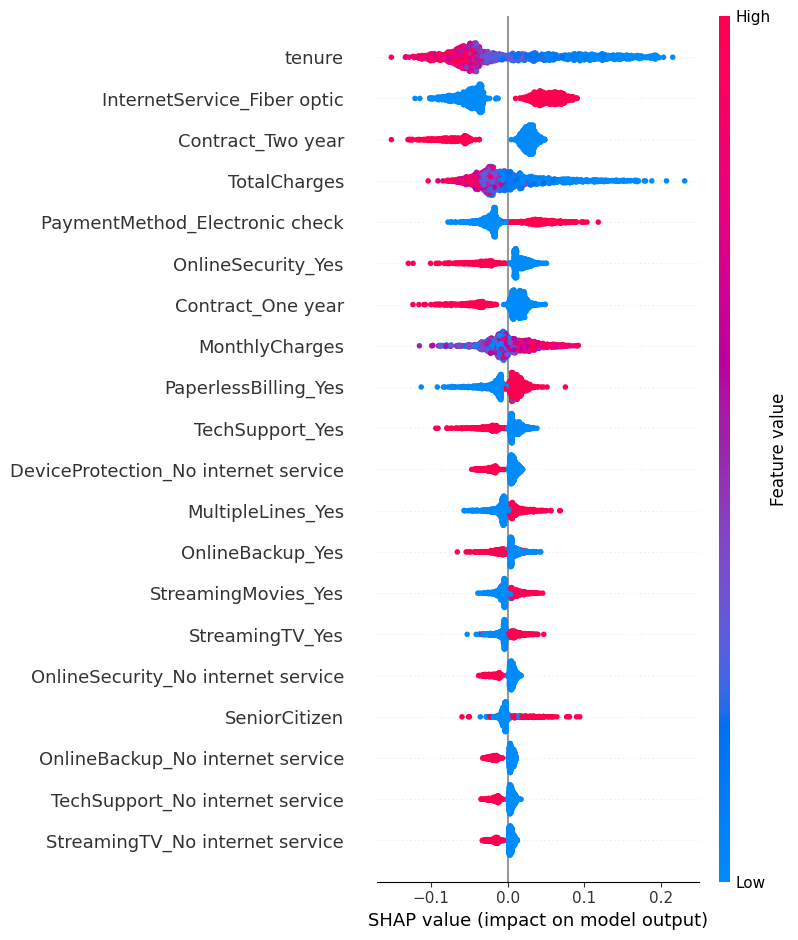

NameError: name 'shap_values_smote' is not defined

In [33]:
# SHAP Baseline
shap.summary_plot(shap_values_baseline[:, :, 1], X_test, title="SHAP — Baseline RF (Imbalanced)")

# SHAP SMOTE
shap.summary_plot(shap_values_smote[:, :, 1], X_test, title="SHAP — SMOTE RF (Balanced)")

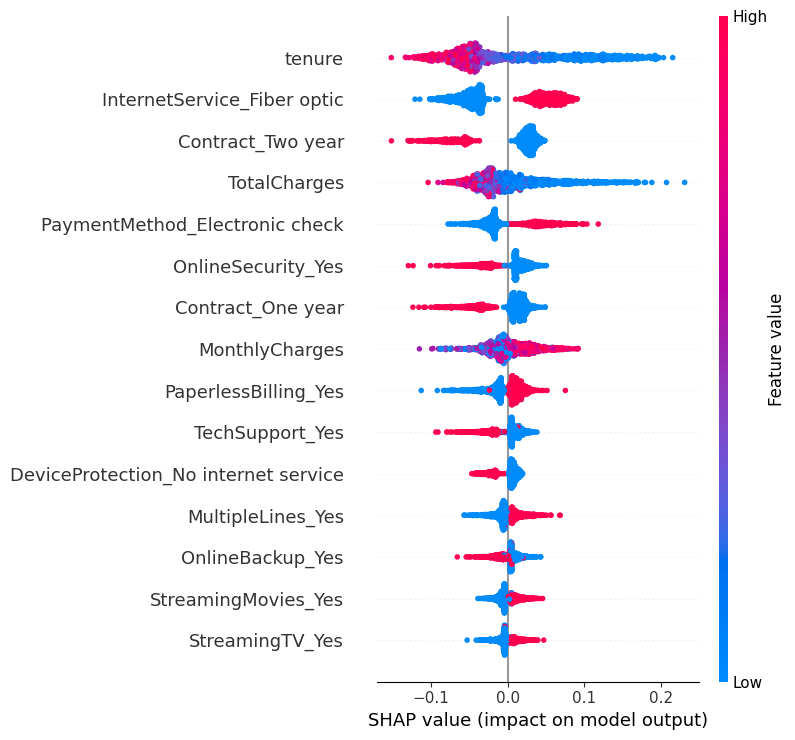

In [34]:
shap.summary_plot(shap_values_baseline[:, :, 1], X_test, 
                  max_display=15,
                  title="SHAP — Baseline RF (Imbalanced)")

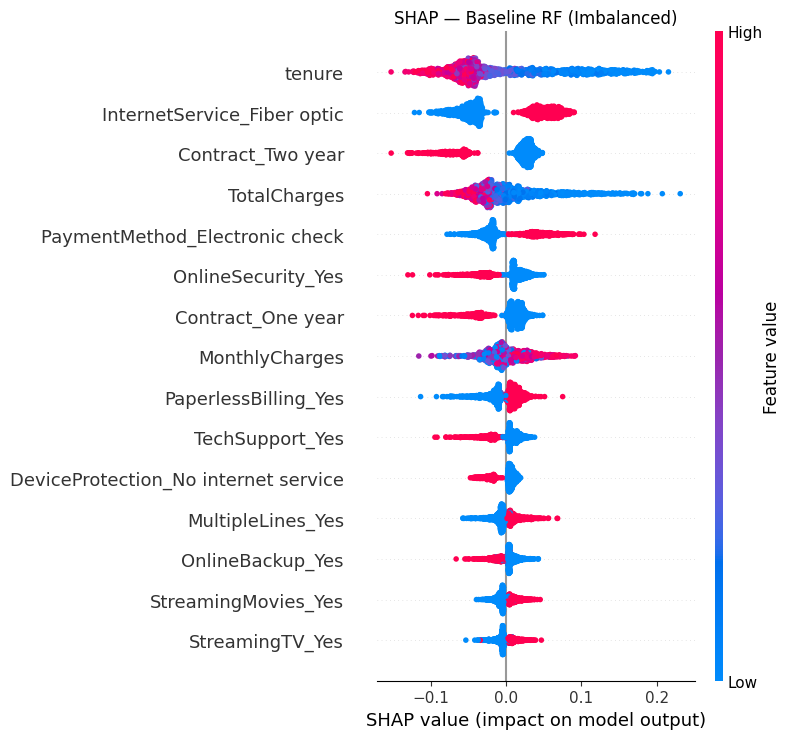

NameError: name 'shap_values_smote' is not defined

<Figure size 640x480 with 0 Axes>

In [35]:
import matplotlib.pyplot as plt

plt.figure()
shap.summary_plot(shap_values_baseline[:, :, 1], X_test, 
                  max_display=15, show=False)
plt.title("SHAP — Baseline RF (Imbalanced)")
plt.tight_layout()
plt.savefig("shap_baseline.png", dpi=150, bbox_inches='tight')
plt.show()

plt.figure()
shap.summary_plot(shap_values_smote[:, :, 1], X_test, 
                  max_display=15, show=False)
plt.title("SHAP — SMOTE RF (Balanced)")
plt.tight_layout()
plt.savefig("shap_smote.png", dpi=150, bbox_inches='tight')
plt.show()

In [39]:
# Calcul SHAP pour le modèle SMOTE
explainer_smote = shap.TreeExplainer(rf_smote)
shap_values_smote = explainer_smote.shap_values(X_test)
print(np.array(shap_values_smote).shape)  # vérification

(1409, 30, 2)


In [40]:
# Importance moyenne par feature
import numpy as np
import pandas as pd

importance_baseline = np.abs(shap_values_baseline[:, :, 1]).mean(axis=0)
importance_smote = np.abs(shap_values_smote[:, :, 1]).mean(axis=0)

df_comparison = pd.DataFrame({
    'Feature': X_test.columns,
    'Baseline_importance': importance_baseline,
    'SMOTE_importance': importance_smote
}).sort_values('Baseline_importance', ascending=False)

print(df_comparison.head(15))

                                 Feature  Baseline_importance  \
1                                 tenure             0.067001   
10           InternetService_Fiber optic             0.051814   
25                     Contract_Two year             0.038272   
3                           TotalCharges             0.034972   
28        PaymentMethod_Electronic check             0.031613   
13                    OnlineSecurity_Yes             0.022193   
24                     Contract_One year             0.021712   
2                         MonthlyCharges             0.021214   
26                  PaperlessBilling_Yes             0.015468   
19                       TechSupport_Yes             0.015309   
16  DeviceProtection_No internet service             0.011177   
9                      MultipleLines_Yes             0.011063   
15                      OnlineBackup_Yes             0.009754   
23                   StreamingMovies_Yes             0.009083   
21                       

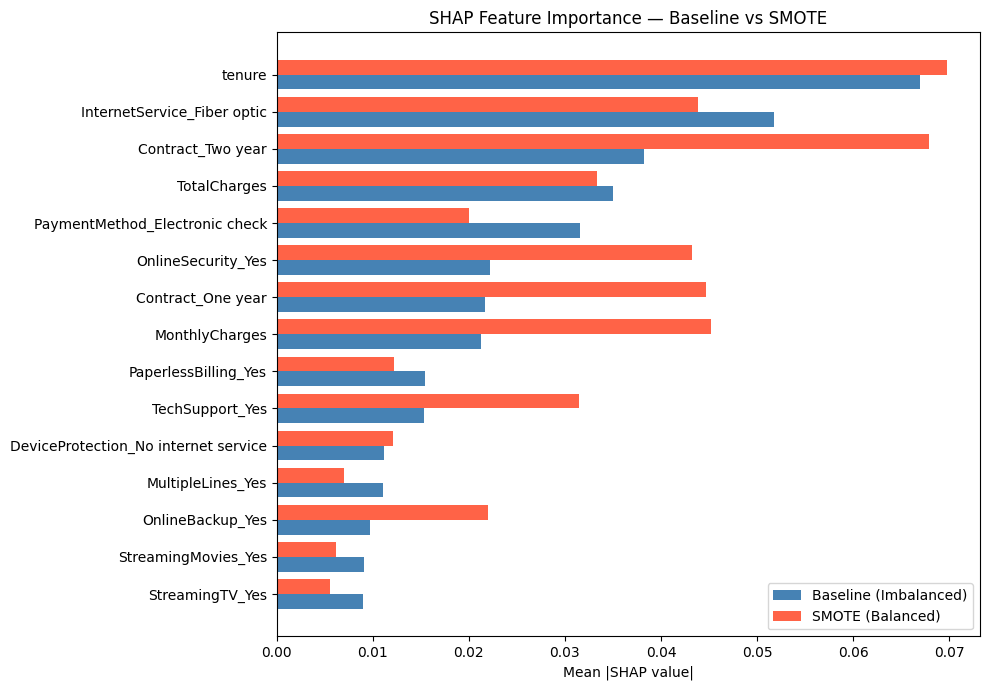

In [54]:
import matplotlib.pyplot as plt

# Top 15 features par importance baseline
df_top15 = df_comparison.head(15).sort_values('Baseline_importance')

fig, ax = plt.subplots(figsize=(10, 7))

x = range(len(df_top15))
ax.barh([i - 0.2 for i in x], df_top15['Baseline_importance'], height=0.4, 
        label='Baseline (Imbalanced)', color='steelblue')
ax.barh([i + 0.2 for i in x], df_top15['SMOTE_importance'], height=0.4, 
        label='SMOTE (Balanced)', color='tomato')

ax.set_yticks(list(x))
ax.set_yticklabels(df_top15['Feature'])
ax.set_xlabel('Mean |SHAP value|')
ax.set_title('SHAP Feature Importance — Baseline vs SMOTE')
ax.legend()
plt.tight_layout()
plt.savefig("shap_comparison.png", dpi=150, bbox_inches='tight')
plt.savefig
plt.show()

In [48]:
import sys
!{sys.executable} -m pip install xgboost

   ---------------------------------------- 0.0/69.5 MB ? eta -:--:--
   ---------------------------------------- 0.0/69.5 MB ? eta -:--:--
   ---------------------------------------- 0.3/69.5 MB ? eta -:--:--
   ---------------------------------------- 0.5/69.5 MB 1.2 MB/s eta 0:00:59
   ---------------------------------------- 0.8/69.5 MB 1.2 MB/s eta 0:00:59
   ---------------------------------------- 0.8/69.5 MB 1.2 MB/s eta 0:00:59
    --------------------------------------- 1.3/69.5 MB 1.2 MB/s eta 0:00:58
    --------------------------------------- 1.6/69.5 MB 1.2 MB/s eta 0:00:59
   - -------------------------------------- 1.8/69.5 MB 1.2 MB/s eta 0:00:58
   - -------------------------------------- 1.8/69.5 MB 1.2 MB/s eta 0:00:58
   - -------------------------------------- 2.4/69.5 MB 1.2 MB/s eta 0:00:57
   - -------------------------------------- 2.6/69.5 MB 1.2 MB/s eta 0:00:57
   - -------------------------------------- 2.9/69.5 MB 1.2 MB/s eta 0:00:57
   - ---------------

In [49]:
from xgboost import XGBClassifier

# XGBoost Baseline (imbalanced)
xgb_baseline = XGBClassifier(n_estimators=100, random_state=42, 
                               eval_metric='logloss', verbosity=0)
xgb_baseline.fit(X_train, y_train)

# XGBoost SMOTE (balanced)
xgb_smote = XGBClassifier(n_estimators=100, random_state=42, 
                            eval_metric='logloss', verbosity=0)
xgb_smote.fit(X_train_sm, y_train_sm)

# Évaluation
from sklearn.metrics import classification_report, accuracy_score

print("=== XGBoost Baseline ===")
y_pred_xgb_base = xgb_baseline.predict(X_test)
print(classification_report(y_test, y_pred_xgb_base))
print("Accuracy:", accuracy_score(y_test, y_pred_xgb_base))

print("=== XGBoost SMOTE ===")
y_pred_xgb_smote = xgb_smote.predict(X_test)
print(classification_report(y_test, y_pred_xgb_smote))
print("Accuracy:", accuracy_score(y_test, y_pred_xgb_smote))

=== XGBoost Baseline ===
              precision    recall  f1-score   support

           0       0.83      0.87      0.85      1035
           1       0.59      0.52      0.55       374

    accuracy                           0.78      1409
   macro avg       0.71      0.69      0.70      1409
weighted avg       0.77      0.78      0.77      1409

Accuracy: 0.7764371894960965
=== XGBoost SMOTE ===
              precision    recall  f1-score   support

           0       0.87      0.80      0.83      1035
           1       0.54      0.67      0.60       374

    accuracy                           0.76      1409
   macro avg       0.71      0.73      0.71      1409
weighted avg       0.78      0.76      0.77      1409

Accuracy: 0.7622427253371186


In [50]:
# SHAP XGBoost Baseline
explainer_xgb_baseline = shap.TreeExplainer(xgb_baseline)
shap_values_xgb_baseline = explainer_xgb_baseline.shap_values(X_test)

# SHAP XGBoost SMOTE
explainer_xgb_smote = shap.TreeExplainer(xgb_smote)
shap_values_xgb_smote = explainer_xgb_smote.shap_values(X_test)

print(np.array(shap_values_xgb_baseline).shape)
print(np.array(shap_values_xgb_smote).shape)

(1409, 30)
(1409, 30)


In [51]:
importance_xgb_baseline = np.abs(shap_values_xgb_baseline).mean(axis=0)
importance_xgb_smote = np.abs(shap_values_xgb_smote).mean(axis=0)

df_comparison_xgb = pd.DataFrame({
    'Feature': X_test.columns,
    'Baseline_importance': importance_xgb_baseline,
    'SMOTE_importance': importance_xgb_smote
}).sort_values('Baseline_importance', ascending=False)

print(df_comparison_xgb.head(15))

                           Feature  Baseline_importance  SMOTE_importance
1                           tenure             0.726402          0.787702
25               Contract_Two year             0.714833          0.880248
2                   MonthlyCharges             0.477095          1.072583
10     InternetService_Fiber optic             0.407655          0.153629
3                     TotalCharges             0.407506          0.400792
24               Contract_One year             0.334990          0.473418
28  PaymentMethod_Electronic check             0.210756          0.082215
13              OnlineSecurity_Yes             0.150466          0.373807
9                MultipleLines_Yes             0.140170          0.142926
26            PaperlessBilling_Yes             0.137400          0.098075
19                 TechSupport_Yes             0.128746          0.334558
23             StreamingMovies_Yes             0.123876          0.177104
11              InternetService_No    

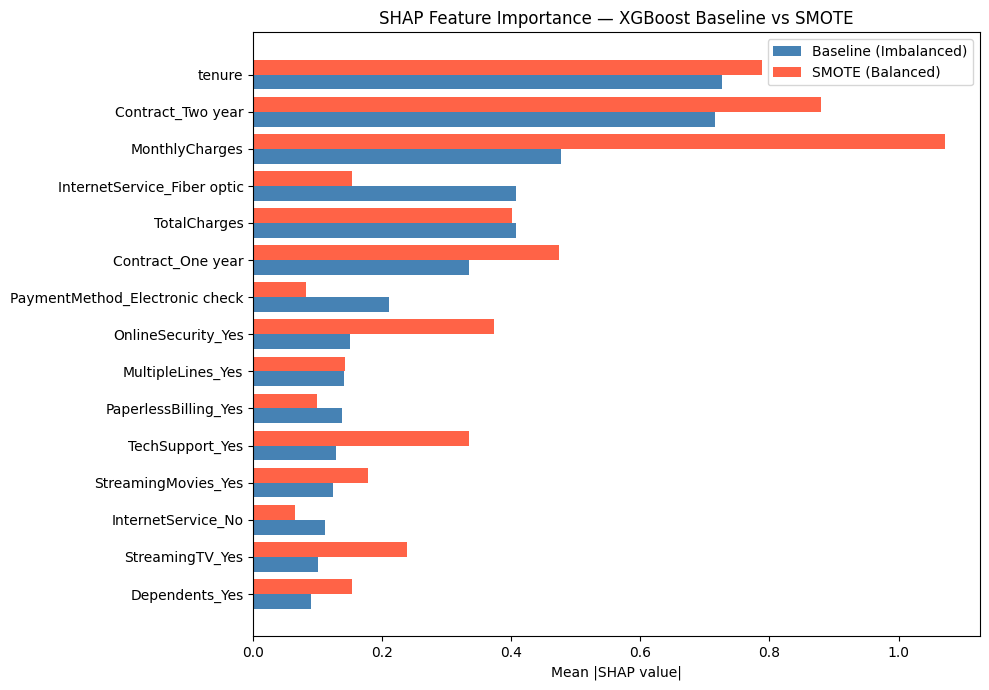

In [56]:
df_top15_xgb = df_comparison_xgb.head(15).sort_values('Baseline_importance')

fig, ax = plt.subplots(figsize=(10, 7))
x = range(len(df_top15_xgb))
ax.barh([i - 0.2 for i in x], df_top15_xgb['Baseline_importance'], height=0.4,
        label='Baseline (Imbalanced)', color='steelblue')
ax.barh([i + 0.2 for i in x], df_top15_xgb['SMOTE_importance'], height=0.4,
        label='SMOTE (Balanced)', color='tomato')

ax.set_yticks(list(x))
ax.set_yticklabels(df_top15_xgb['Feature'])
ax.set_xlabel('Mean |SHAP value|')
ax.set_title('SHAP Feature Importance — XGBoost Baseline vs SMOTE')
ax.legend()
plt.tight_layout()
plt.savefig("shap_comparison_xgb.png", dpi=150, bbox_inches='tight')
plt.savefig
plt.show()

In [53]:
# Merge RF et XGBoost pour comparaison globale
df_final = pd.DataFrame({
    'Feature': X_test.columns,
    'RF_Baseline': np.abs(shap_values_baseline[:, :, 1]).mean(axis=0),
    'RF_SMOTE': np.abs(shap_values_smote[:, :, 1]).mean(axis=0),
    'XGB_Baseline': importance_xgb_baseline,
    'XGB_SMOTE': importance_xgb_smote
}).sort_values('RF_Baseline', ascending=False)

df_final['RF_shift'] = ((df_final['RF_SMOTE'] - df_final['RF_Baseline']) / df_final['RF_Baseline'] * 100).round(1)
df_final['XGB_shift'] = ((df_final['XGB_SMOTE'] - df_final['XGB_Baseline']) / df_final['XGB_Baseline'] * 100).round(1)

print(df_final[['Feature', 'RF_Baseline', 'RF_SMOTE', 'RF_shift', 'XGB_Baseline', 'XGB_SMOTE', 'XGB_shift']].head(15).to_string())

                                 Feature  RF_Baseline  RF_SMOTE  RF_shift  XGB_Baseline  XGB_SMOTE   XGB_shift
1                                 tenure     0.067001  0.069721       4.1      0.726402   0.787702    8.400000
10           InternetService_Fiber optic     0.051814  0.043878     -15.3      0.407655   0.153629  -62.299999
25                     Contract_Two year     0.038272  0.067885      77.4      0.714833   0.880248   23.100000
3                           TotalCharges     0.034972  0.033306      -4.8      0.407506   0.400792   -1.600000
28        PaymentMethod_Electronic check     0.031613  0.019995     -36.7      0.210756   0.082215  -61.000000
13                    OnlineSecurity_Yes     0.022193  0.043213      94.7      0.150466   0.373807  148.399994
24                     Contract_One year     0.021712  0.044737     106.0      0.334990   0.473418   41.299999
2                         MonthlyCharges     0.021214  0.045185     113.0      0.477095   1.072583  124.800003
2

In [57]:
import joblib

joblib.dump(rf_smote, "rf_smote.pkl")
joblib.dump(xgb_smote, "xgb_smote.pkl")

# Sauvegarder aussi les colonnes de X_test pour garder le bon ordre des features
import json
json.dump(list(X_test.columns), open("feature_columns.json", "w"))

print("Modèles sauvegardés ✅")

Modèles sauvegardés ✅


In [59]:
import sys
!{sys.executable} -m pip install streamlit

In [60]:
import os
print(os.getcwd())

C:\Users\hp\mini_projet_ML


In [62]:
print(list(X_test.columns))

['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges', 'gender_Male', 'Partner_Yes', 'Dependents_Yes', 'PhoneService_Yes', 'MultipleLines_No phone service', 'MultipleLines_Yes', 'InternetService_Fiber optic', 'InternetService_No', 'OnlineSecurity_No internet service', 'OnlineSecurity_Yes', 'OnlineBackup_No internet service', 'OnlineBackup_Yes', 'DeviceProtection_No internet service', 'DeviceProtection_Yes', 'TechSupport_No internet service', 'TechSupport_Yes', 'StreamingTV_No internet service', 'StreamingTV_Yes', 'StreamingMovies_No internet service', 'StreamingMovies_Yes', 'Contract_One year', 'Contract_Two year', 'PaperlessBilling_Yes', 'PaymentMethod_Credit card (automatic)', 'PaymentMethod_Electronic check', 'PaymentMethod_Mailed check']
